# Stablecoin Depeg Early Warning System
## Feature Engineering

Reads the cleansed per-coin parquets from S3, engineers a full feature set
per coin, stacks all coins into a pooled dataset, then uses CatBoost
built-in feature selection to identify the optimal feature subset.

**Input:**  `s3://{BUCKET}/data/ify/cleansed/{coin}_5m_clean.parquet`
**Output:** `s3://{BUCKET}/data/ify/features/pooled_5m.parquet`

## 1. Setup

In [3]:
pip install -qq catboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
from matplotlib.patches import Patch
import warnings, time

warnings.filterwarnings("ignore")

# plot style 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

# colour palette 
ORANGE = "#F5AC37"
RED    = "#E84142"
GREEN  = "#27AE60"
DARK   = "#2C3E50"
LGRAY  = "#BDC3C7"
ACCENT = "#2775CA"

COIN_COLORS = {
    "usdt":  "#26A17B",
    "usdc":  "#2775CA",
    "dai":   "#F5AC37",
    "busd":  "#F0B90B",
    "ust":   "#E84142",
    "usde":  "#9B59B6",
    "rlusd": "#00AAE4",
}

COIN_TYPE = {
    "usdt":  "fiat_backed",
    "usdc":  "fiat_backed",
    "busd":  "fiat_backed",
    "rlusd": "fiat_backed",
    "dai":   "crypto_backed",
    "ust":   "algorithmic",
    "usde":  "yield_bearing",
}

COINS = ["usdt", "usdc", "dai", "busd", "ust", "usde", "rlusd"]

# 5-min bar constants
BARS_1H  = 12
BARS_6H  = 72
BARS_24H = 288
BARS_7D  = 2016
BARS_30D = 8640

# ── local paths ───────────────────────────────────────────────────────────────
CLEANSED_DIR = Path("../data/processed/cleansed")
FEATURES_DIR = Path("../data/processed/features")
PLOTS_DIR    = Path("../data/processed/features")

FEATURES_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = ["depeg_next_1h", "depeg_next_30min"]

print("Setup complete.")
print(f"Reading from: {CLEANSED_DIR}")
print(f"Writing to:   {FEATURES_DIR}")
print(f"Targets:      {TARGETS}")

Setup complete.
Reading from: ../data/processed/cleansed
Writing to:   ../data/processed/features
Targets:      ['depeg_next_1h', 'depeg_next_30min']


## 2. Download Cleansed Data from S3

In [5]:
for coin in COINS:
    fname = f"{coin}_5m_clean.parquet"
    local = CLEANSED_DIR / fname
    if local.exists():
        print(f"  found  {fname}")
    else:
        print(f"  MISSING  {fname}  — expected at {local}")

  found  usdt_5m_clean.parquet
  found  usdc_5m_clean.parquet
  found  dai_5m_clean.parquet
  found  busd_5m_clean.parquet
  found  ust_5m_clean.parquet
  found  usde_5m_clean.parquet
  found  rlusd_5m_clean.parquet


## 3. Load Cleansed Data

In [6]:
t0 = time.time()

dfs = {}
for coin in COINS:
    path = CLEANSED_DIR / f'{coin}_5m_clean.parquet'
    df   = pd.read_parquet(path)
    dfs[coin] = df
    print(f'{coin.upper():6s}: {len(df):>9,} rows  |  '
          f'{df.index.min().date()} to {df.index.max().date()}  |  '
          f'{len(df.columns)} cols')

    # confirm depeg_next_15min was written by Notebook 1
    assert 'depeg_next_15min' in df.columns, \
        f'depeg_next_15min missing from {coin} cleansed parquet. Re-run Notebook 1.'
    # confirm depeg_next_30min exists from the raw parquets
    assert 'depeg_next_30min' in df.columns, \
        f'depeg_next_30min missing from {coin} cleansed parquet.'

print(f'\nLoad completed in {time.time()-t0:.1f}s')

USDT  :   897,936 rows  |  2017-08-17 to 2026-02-28  |  84 cols
USDC  :   775,506 rows  |  2018-10-16 to 2026-02-28  |  96 cols
DAI   :   828,963 rows  |  2018-04-13 to 2026-02-28  |  58 cols
BUSD  :   370,848 rows  |  2019-09-20 to 2023-03-31  |  53 cols
UST   :   153,961 rows  |  2020-11-23 to 2022-05-12  |  58 cols
USDE  :   200,928 rows  |  2024-04-02 to 2026-02-28  |  53 cols
RLUSD :    96,192 rows  |  2025-04-01 to 2026-02-28  |  56 cols

Load completed in 0.4s


## 4. Universal Base Features

These features are engineered from columns that exist for all 7 coins.
Every row in the pooled dataset will have a non-null value for every
universal feature. No CatBoost NaN routing needed for these.

All rolling windows are backward-looking only. `rolling(N).mean()` in
pandas computes the mean of the N rows ending at the current row, so
it only uses past and current data. We never use `shift(-N)` in any
feature definition.

In [7]:
t0 = time.time()

def add_universal_features(df, coin, price_dev_others):
    '''
    Parameters
    ----------
    df               : cleansed DataFrame for this coin (DatetimeIndex)
    coin             : coin name string
    price_dev_others : dict of {coin: Series} — price_dev for all other coins,
                       pre-loaded so we do not re-read files inside this function

    Returns
    -------
    df : same DataFrame with u_ prefixed columns added in-place copy
    '''
    df = df.copy()

    close = df['coinapi_close']
    dev   = df['price_dev']

    # price deviation features
    df['u_price_dev_bps']     = dev * 10_000
    df['u_abs_dev_bps']       = dev.abs() * 10_000

    # rolling price volatility — 1h and 6h windows
    df['u_volatility_1h']     = close.rolling(BARS_1H, min_periods=2).std()
    df['u_volatility_6h']     = close.rolling(BARS_6H, min_periods=2).std()

    # 6-hour price momentum
    df['u_price_momentum_6h'] = close - close.shift(BARS_6H)

    # 7-day price z-score
    roll_7d = close.rolling(BARS_7D, min_periods=100)
    df['u_price_z_score_7d']  = (close - roll_7d.mean()) / roll_7d.std()

    # intrabar range — microstructure stress proxy
    hi = df['coinapi_high']
    lo = df['coinapi_low']
    df['u_intrabar_range']    = (hi - lo) / close.replace(0, np.nan)

    # volume features — coinapi_tick_count as universal proxy
    ticks = df['coinapi_tick_count']

    roll_6h_vol = ticks.rolling(BARS_6H, min_periods=6).mean()
    df['u_volume_surge_6h']   = ticks / roll_6h_vol.replace(0, np.nan)

    roll_7d_vol = ticks.rolling(BARS_7D, min_periods=100)
    df['u_volume_z_score_7d'] = (ticks - roll_7d_vol.mean()) / roll_7d_vol.std()

    df['u_abnormal_volume_flag'] = (df['u_volume_z_score_7d'] > 3).astype(float)

    # cross-market features — returns and volatility, not raw levels
    btc     = df['binance_btc_close']
    eth     = df['binance_eth_close']
    btc_ret = btc.pct_change()

    df['u_btc_return_24h']      = btc.pct_change(BARS_24H)
    df['u_eth_return_24h']      = eth.pct_change(BARS_24H)
    df['u_btc_volatility_24h']  = btc_ret.rolling(BARS_24H, min_periods=12).std()

    # macro features
    df['u_vix']        = df['vix']
    df['u_dxy']        = df['dxy']
    df['u_fear_greed'] = df['fear_greed']

    # cross-coin stress features — individual columns for top-3 correlated pairs
    # confirmed empirically: USDC->USDT AUC=0.958, DAI->USDT AUC=0.893
    for other in ['usdt', 'usdc', 'dai']:
        if other != coin:
            df[f'u_cross_{other}_dev'] = (
                price_dev_others[other].reindex(df.index)
            )

    # catch-all: max |price_dev| across ALL other coins
    other_coins = [c for c in COINS if c != coin]
    df['u_other_stable_max_dev'] = pd.concat(
        [price_dev_others[c].reindex(df.index).abs() for c in other_coins],
        axis=1
    ).max(axis=1)

    # temporal features — low standalone AUC but contribute to tree interactions
    df['u_hour_of_day'] = df.index.hour
    df['u_day_of_week'] = df.index.dayofweek

    # coin type categorical — CatBoost handles natively, no one-hot needed
    df['u_coin_type'] = COIN_TYPE[coin]

    return df


# pre-load price_dev Series for all coins — used for cross-coin features
price_dev_all = {coin: dfs[coin]['price_dev'] for coin in COINS}

print('Engineering universal base features...')
for coin in COINS:
    dfs[coin] = add_universal_features(dfs[coin], coin, price_dev_all)
    u_cols    = [c for c in dfs[coin].columns if c.startswith('u_')]
    print(f'  {coin.upper():6s}: {len(u_cols)} universal features added')

print(f'\nUniversal features completed in {time.time()-t0:.1f}s')

Engineering universal base features...
  USDT  : 22 universal features added
  USDC  : 22 universal features added
  DAI   : 22 universal features added
  BUSD  : 23 universal features added
  UST   : 23 universal features added
  USDE  : 23 universal features added
  RLUSD : 23 universal features added

Universal features completed in 1.1s


## 5. Supplementary Features + Availability Flags

Supplementary features use data that exists only for a subset of coins.
For coins without the source data the feature is left as NaN — CatBoost
learns an optimal NaN split direction natively.

Availability flags are always 0 or 1, never NaN. They make structural
absences explicit so CatBoost routes NaN rows intentionally rather than
having to infer coin identity from the NaN pattern alone.

| Feature group | Coins with data | Coins with NaN |
|---|---|---|
| Binance CEX | USDT | all others |
| Curve 3pool | USDT, USDC, DAI | BUSD, UST, USDE, RLUSD |
| Coin-specific DEX | USDE, RLUSD | all others |
| On-chain flow | all except UST | UST |

In [8]:
t0 = time.time()

# exact curve net-sell column name per coin — confirmed from raw parquet audit
CURVE_NET_SELL_COL = {
    'usdt':  'curve_3pool_usdt_net_sell_volume_usd',
    'usdc':  'curve_3pool_usdc_net_sell_volume_usd',
    'dai':   'curve_3pool_dai_net_sell_volume_usd',
    'usde':  'curve_usde_usdc_usde_net_sell_volume_usd',
    'rlusd': 'curve_rlusd_usdc_rlusd_net_sell_volume_usd',
    'busd':  None,
    'ust':   None,
}

def add_supplementary_features(df, coin):
    '''
    Engineer supplementary features and availability flags for one coin.

    s_ prefixed columns may be NaN where source data does not exist.
    f_ prefixed columns are always 0 or 1, never NaN.

    Parameters
    ----------
    df   : DataFrame after universal feature engineering
    coin : coin name string

    Returns
    -------
    df : same DataFrame with s_ and f_ columns added
    '''
    df = df.copy()

    # availability flags 
    df['f_has_binance'] = int(coin == 'usdt')
    df['f_has_3pool']   = int(coin in ('usdt', 'usdc', 'dai'))
    df['f_has_own_dex'] = int(coin in ('usde', 'rlusd'))
    df['f_has_onchain'] = int(coin != 'ust')

    # ─Binance CEX features (USDT only) 
    if 'binance_usdcusdt_spread_proxy' in df.columns:
        spread  = df['binance_usdcusdt_spread_proxy']
        roll_7d = spread.rolling(BARS_7D, min_periods=100)
        df['s_spread_z_score_7d'] = (spread - roll_7d.mean()) / roll_7d.std()
        df['s_spread_change_6h']  = spread - spread.shift(BARS_6H)

    if 'binance_usdcusdt_buy_ratio' in df.columns:
        buy = df['binance_usdcusdt_buy_ratio']
        df['s_buy_ratio_change_6h'] = buy - buy.shift(BARS_6H)

    if 'binance_usdcusdt_volume' in df.columns:
        bvol    = df['binance_usdcusdt_volume']
        roll_6h = bvol.rolling(BARS_6H, min_periods=6).mean()
        df['s_binance_volume_surge_6h'] = bvol / roll_6h.replace(0, np.nan)

    # ── Curve DEX features (USDT, USDC, DAI, USDE, RLUSD) ───────────────────
    net_sell_col = CURVE_NET_SELL_COL.get(coin)
    if net_sell_col and net_sell_col in df.columns:
        ns = df[net_sell_col]

        df['s_pool_net_sell_1h'] = ns.rolling(BARS_1H, min_periods=1).sum()
        df['s_pool_net_sell_6h'] = ns.rolling(BARS_6H, min_periods=1).sum()

        df['s_pool_imbalance_velocity_1h'] = (
            df['s_pool_net_sell_1h'] - df['s_pool_net_sell_1h'].shift(BARS_1H)
        )

        roll_30d = ns.rolling(BARS_30D, min_periods=100)
        df['s_pool_net_sell_z_score_30d'] = (
            (ns - roll_30d.mean()) / roll_30d.std()
        )

        for lag in [1, 3, 6, 12]:
            df[f's_pool_net_sell_lag{lag}'] = ns.shift(lag)

    # on-chain flow features (all except UST) 
    # USDT uses total_net_flow_usd (treasury + tron, 16K non-zero rows)
    # all others use net_flow_usd (mint - burn)
    # confirmed: net_flow_usd for USDT has only 584 non-zero rows — wrong signal
    flow_col = 'total_net_flow_usd' if coin == 'usdt' else 'net_flow_usd'
    if flow_col in df.columns:
        flow      = df[flow_col]
        roll_7d_f = flow.rolling(BARS_7D, min_periods=100)

        df['s_net_flow_z_score_7d'] = (flow - roll_7d_f.mean()) / roll_7d_f.std()
        df['s_net_flow_24h']        = flow.rolling(BARS_24H, min_periods=1).sum()

        for lag in [1, 3, 6, 12]:
            df[f's_net_flow_lag{lag}'] = flow.shift(lag)

    # mint-to-burn ratio — > 1 = confidence, < 1 = redemption pressure
    if 'mint_volume_usd' in df.columns and 'burn_volume_usd' in df.columns:
        mint = df['mint_volume_usd']
        burn = df['burn_volume_usd']
        df['s_mint_burn_ratio'] = mint / (burn + 1)

    return df


print('Engineering supplementary features and availability flags...')
for coin in COINS:
    dfs[coin] = add_supplementary_features(dfs[coin], coin)
    s_cols = [c for c in dfs[coin].columns if c.startswith('s_')]
    f_cols = [c for c in dfs[coin].columns if c.startswith('f_')]
    print(f'  {coin.upper():6s}: {len(s_cols)} supplementary  |  {len(f_cols)} flags')

print(f'\nSupplementary features completed in {time.time()-t0:.1f}s')

Engineering supplementary features and availability flags...
  USDT  : 13 supplementary  |  4 flags
  USDC  : 19 supplementary  |  4 flags
  DAI   : 15 supplementary  |  4 flags
  BUSD  : 7 supplementary  |  4 flags
  UST   : 0 supplementary  |  4 flags
  USDE  : 15 supplementary  |  4 flags
  RLUSD : 15 supplementary  |  4 flags

Supplementary features completed in 0.9s


## 6. Feature Inventory

Total engineered features: 46
  Universal (u_):     23
  Supplementary (s_): 19
  Flags (f_):         4


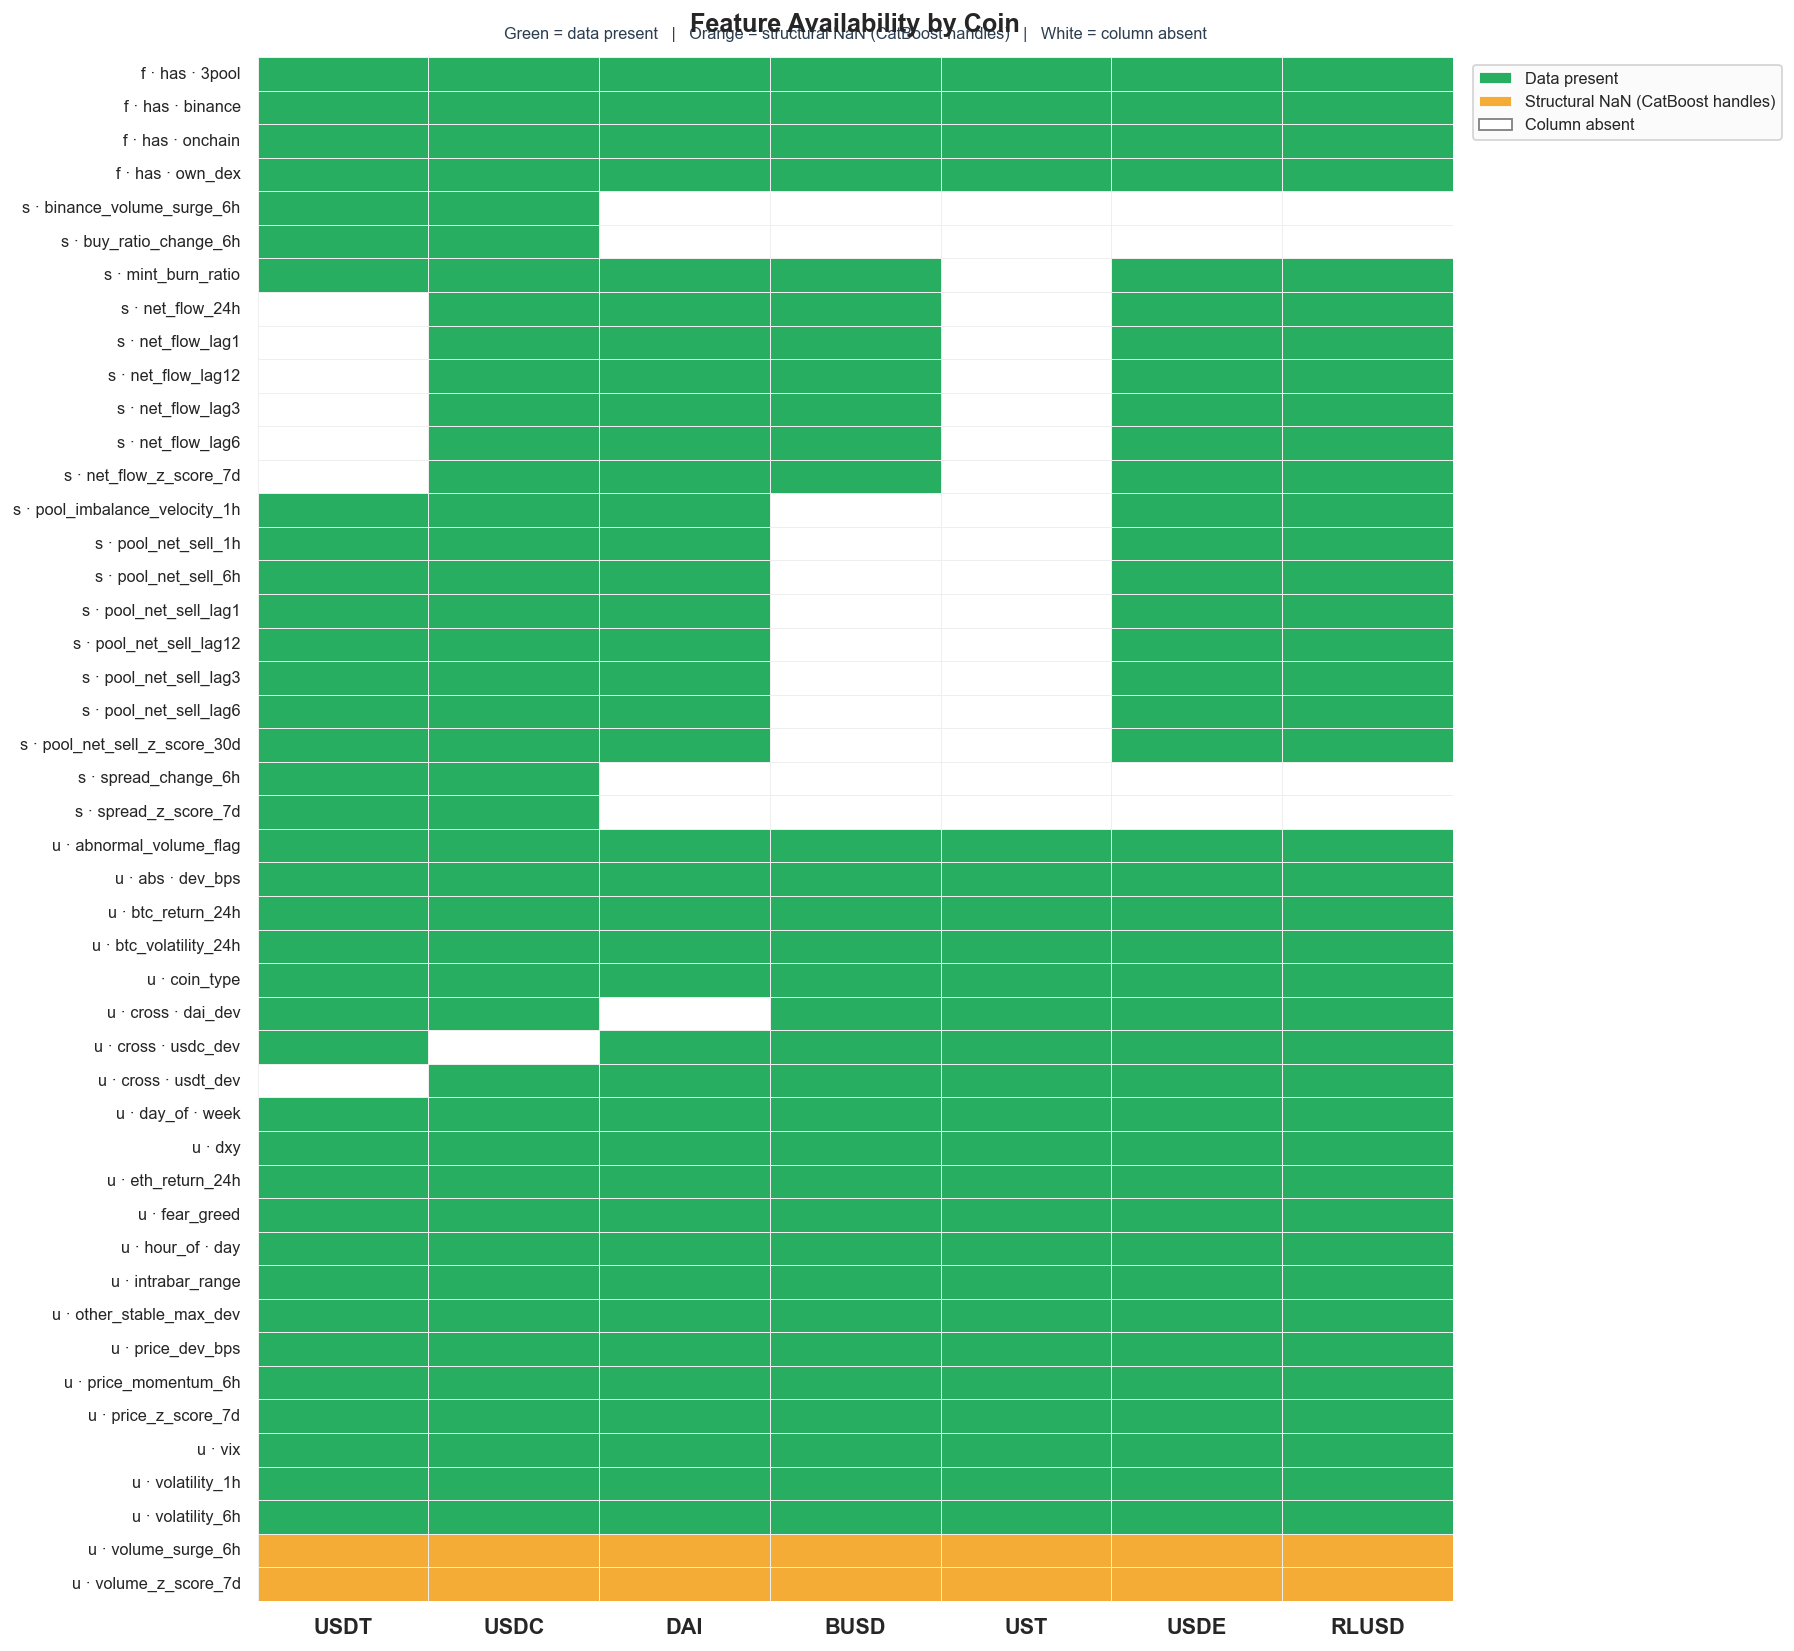


Feature inventory completed in 0.5s


In [ ]:
t0 = time.time()

# collect all u_, s_, f_ columns across all coins
all_feat_cols = sorted({
    c for coin in COINS
    for c in dfs[coin].columns
    if c.startswith(('u_', 's_', 'f_'))
})

# availability matrix: 'yes' = data present, 'nan' = structural absence
avail = {}
for coin in COINS:
    df  = dfs[coin]
    row = {}
    for feat in all_feat_cols:
        if feat not in df.columns:
            row[feat] = 'absent'
        elif df[feat].notna().any():
            row[feat] = 'yes'
        else:
            row[feat] = 'nan'
    avail[coin.upper()] = row

avail_df  = pd.DataFrame(avail).T
avail_num = avail_df.replace({'yes': 1, 'nan': 0.5, 'absent': 0})

n_feats = len(all_feat_cols)

print(f'Total engineered features: {n_feats}')
print(f'  Universal (u_):     {sum(1 for c in all_feat_cols if c.startswith("u_"))}')
print(f'  Supplementary (s_): {sum(1 for c in all_feat_cols if c.startswith("s_"))}')
print(f'  Flags (f_):         {sum(1 for c in all_feat_cols if c.startswith("f_"))}')


fig_h = max(10, n_feats * 0.28)
fig, ax = plt.subplots(figsize=(14, fig_h))

sns.heatmap(
    avail_num.astype(float).T,
    cmap=['white', ORANGE, GREEN],
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='#EEEEEE',
    cbar=False,
    ax=ax,
    yticklabels=True,
    xticklabels=True,
)

# coin labels on x-axis — large and bold
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight='bold')

# feature labels on y-axis — readable at 9pt with short prefix stripped
short_labels = [
    c.replace('u_', 'u · ')
     .replace('s_', 's · ')
     .replace('f_', 'f · ')
    for c in all_feat_cols
]
ax.set_yticklabels(short_labels, fontsize=9)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(
    'Feature Availability by Coin',
    fontsize=14, fontweight='bold', pad=14
)
ax.text(
    0.5, 1.01,
    'Green = data present   |   Orange = structural NaN (CatBoost handles)   |   White = column absent',
    transform=ax.transAxes,
    ha='center', va='bottom', fontsize=9, color=DARK
)

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor=GREEN,   label='Data present'),
        Patch(facecolor=ORANGE,  label='Structural NaN (CatBoost handles)'),
        Patch(facecolor='white', edgecolor='grey', label='Column absent'),
    ],
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    fontsize=9,
    frameon=True,
)

plt.tight_layout()
plt.show()
print(f'\nFeature inventory completed in {time.time()-t0:.1f}s')

## 7. Stack All Coins into Pooled Dataset

Rolling windows must run per-coin before pooling. If we pooled first,
a USDT 30-day z-score would be contaminated by USDC values from a
different date range. Engineer per-coin first, then stack.

We train on onset rows only (depeg==0). The model predicts ONSET, not
continuation. Including already-depegged rows teaches the model a
tautological lesson: broken price predicts broken price.

In [10]:
t0 = time.time()

# feature columns for the model — u_ and s_ numeric, f_ flags
# u_coin_type is categorical and handled separately
feat_cols = [c for c in all_feat_cols if c != 'u_coin_type']
cat_cols  = ['u_coin_type']

# metadata columns that travel to Notebook 3 but are NOT model inputs
# depeg_next_30min replaces depeg_next_4h throughout
meta_cols = ['coin', 'depeg', 'depeg_next_1h', 'depeg_next_30min', 'severity']

pieces = []
for coin in COINS:
    df = dfs[coin].copy()

    # onset rows only — depeg == 0 means currently stable
    onset = df[df['depeg'] == 0].copy()

    # select only columns we need — guards against missing columns per coin
    keep  = [c for c in meta_cols + cat_cols + feat_cols if c in onset.columns]
    onset = onset[keep]
    onset['u_coin_type'] = COIN_TYPE[coin]

    n_pos_1h  = int((onset['depeg_next_1h']   == 1).sum())
    n_pos_30m = int((onset['depeg_next_30min'] == 1).sum())
    print(f'{coin.upper():6s}: {len(onset):>9,} onset rows  |  '
          f'1h: {n_pos_1h:,} pos ({n_pos_1h/len(onset)*100:.2f}%)  |  '
          f'30min: {n_pos_30m:,} pos ({n_pos_30m/len(onset)*100:.2f}%)')

    pieces.append(onset)

# sort by timestamp after pooling — required for correct chronological split
pooled = pd.concat(pieces).sort_index()

print(f'\nPooled shape: {pooled.shape[0]:,} rows x {pooled.shape[1]} cols')
print(f'Overall depeg_next_1h rate:   {pooled["depeg_next_1h"].mean():.3%}')
print(f'Overall depeg_next_30min rate: {pooled["depeg_next_30min"].mean():.3%}')
print(f'\nPooling completed in {time.time()-t0:.1f}s')

USDT  :   816,073 onset rows  |  1h: 7,655 pos (0.94%)  |  30min: 4,771 pos (0.58%)
USDC  :   732,176 onset rows  |  1h: 2,808 pos (0.38%)  |  30min: 1,743 pos (0.24%)
DAI   :   740,510 onset rows  |  1h: 10,718 pos (1.45%)  |  30min: 6,734 pos (0.91%)
BUSD  :   369,826 onset rows  |  1h: 413 pos (0.11%)  |  30min: 261 pos (0.07%)
UST   :   145,791 onset rows  |  1h: 1,447 pos (0.99%)  |  30min: 927 pos (0.64%)
USDE  :   200,837 onset rows  |  1h: 122 pos (0.06%)  |  30min: 82 pos (0.04%)
RLUSD :    96,192 onset rows  |  1h: 0 pos (0.00%)  |  30min: 0 pos (0.00%)

Pooled shape: 3,101,405 rows x 51 cols
Overall depeg_next_1h rate:   0.747%
Overall depeg_next_30min rate: 0.468%

Pooling completed in 2.3s


## 8. Coin Contribution Analysis

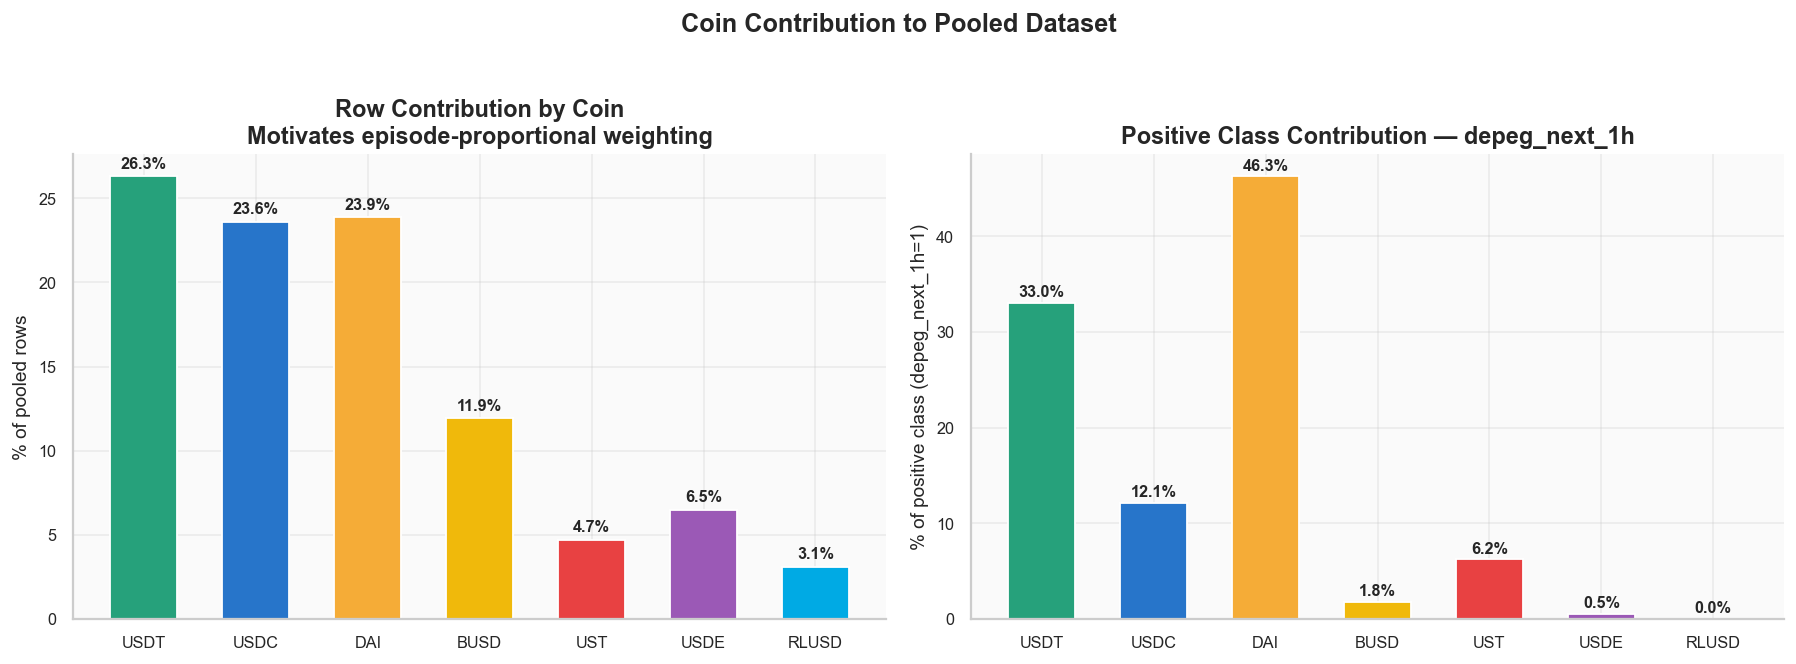

Coin contribution analysis completed in 1.6s


In [ ]:
t0 = time.time()

coin_stats = pd.DataFrame([{
    'coin':     coin.upper(),
    'rows':     (pooled['coin'] == coin).sum(),
    'pos_1h':   ((pooled['coin'] == coin) & (pooled['depeg_next_1h']   == 1)).sum(),
    'pos_30min':((pooled['coin'] == coin) & (pooled['depeg_next_30min'] == 1)).sum(),
} for coin in COINS])

coin_stats['row_pct']    = coin_stats['rows']    / coin_stats['rows'].sum()   * 100
coin_stats['pos_pct_1h'] = coin_stats['pos_1h']  / coin_stats['pos_1h'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(
    coin_stats['coin'], coin_stats['row_pct'],
    color=[COIN_COLORS[c.lower()] for c in coin_stats['coin']],
    edgecolor='white', width=0.6
)
for b, v in zip(bars1, coin_stats['row_pct']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set(ylabel='% of pooled rows', xlabel='',
            title='Row Contribution by Coin\nMotivates episode-proportional weighting')
sns.despine(ax=axes[0])

bars2 = axes[1].bar(
    coin_stats['coin'], coin_stats['pos_pct_1h'],
    color=[COIN_COLORS[c.lower()] for c in coin_stats['coin']],
    edgecolor='white', width=0.6
)
for b, v in zip(bars2, coin_stats['pos_pct_1h']):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set(ylabel='% of positive class (depeg_next_1h=1)', xlabel='',
            title='Positive Class Contribution — depeg_next_1h')
sns.despine(ax=axes[1])

fig.suptitle('Coin Contribution to Pooled Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Coin contribution analysis completed in {time.time()-t0:.1f}s')

## 9. Pre-Selection: Univariate AUC on Engineered Features

In [12]:
t0 = time.time()

'''
Rank all engineered features by univariate AUC against depeg_next_1h.
Adjusted AUC = max(auc, 1-auc) so inverse correlations register equally.

u_coin_type excluded — categorical, no scalar AUC.
depeg_next_30min excluded — it is a target, not a feature.
'''

TARGET = 'depeg_next_1h'

# numeric feature columns only — exclude categorical and all target columns
num_feats = [
    c for c in feat_cols
    if pooled[c].dtype != object
    and c not in ['depeg_next_1h', 'depeg_next_30min']
]

results = []
for col in num_feats:
    valid = pooled[[col, TARGET]].dropna()
    if len(valid) < 100:
        continue
    if valid[TARGET].nunique() < 2:
        continue
    try:
        raw = roc_auc_score(valid[TARGET], valid[col])
        results.append({
            'feature': col,
            'auc':     round(max(raw, 1-raw), 4),
            'type':    'universal'     if col.startswith('u_') else
                       'flag'          if col.startswith('f_') else
                       'supplementary',
        })
    except Exception:
        continue

auc_df = (pd.DataFrame(results)
            .sort_values('auc', ascending=False)
            .reset_index(drop=True))

print(f'Univariate AUC computed for {len(auc_df)} features')
print(f'\nTop 20 by AUC:')
display(auc_df.head(20))
print(f'\nCompleted in {time.time()-t0:.1f}s')

Univariate AUC computed for 43 features

Top 20 by AUC:


,feature,auc,type
0,u_abs_dev_bps,0.9645,universal
1,u_volatility_6h,0.9490,universal
2,u_volatility_1h,0.9108,universal
3,u_other_stable_max_dev,0.7734,universal
4,u_cross_usdc_dev,0.7548,universal
5,u_dxy,0.7446,universal
6,u_price_dev_bps,0.7302,universal
7,u_intrabar_range,0.7024,universal
8,u_cross_usdt_dev,0.7019,universal
9,u_btc_volatility_24h,0.6564,universal



Completed in 14.9s


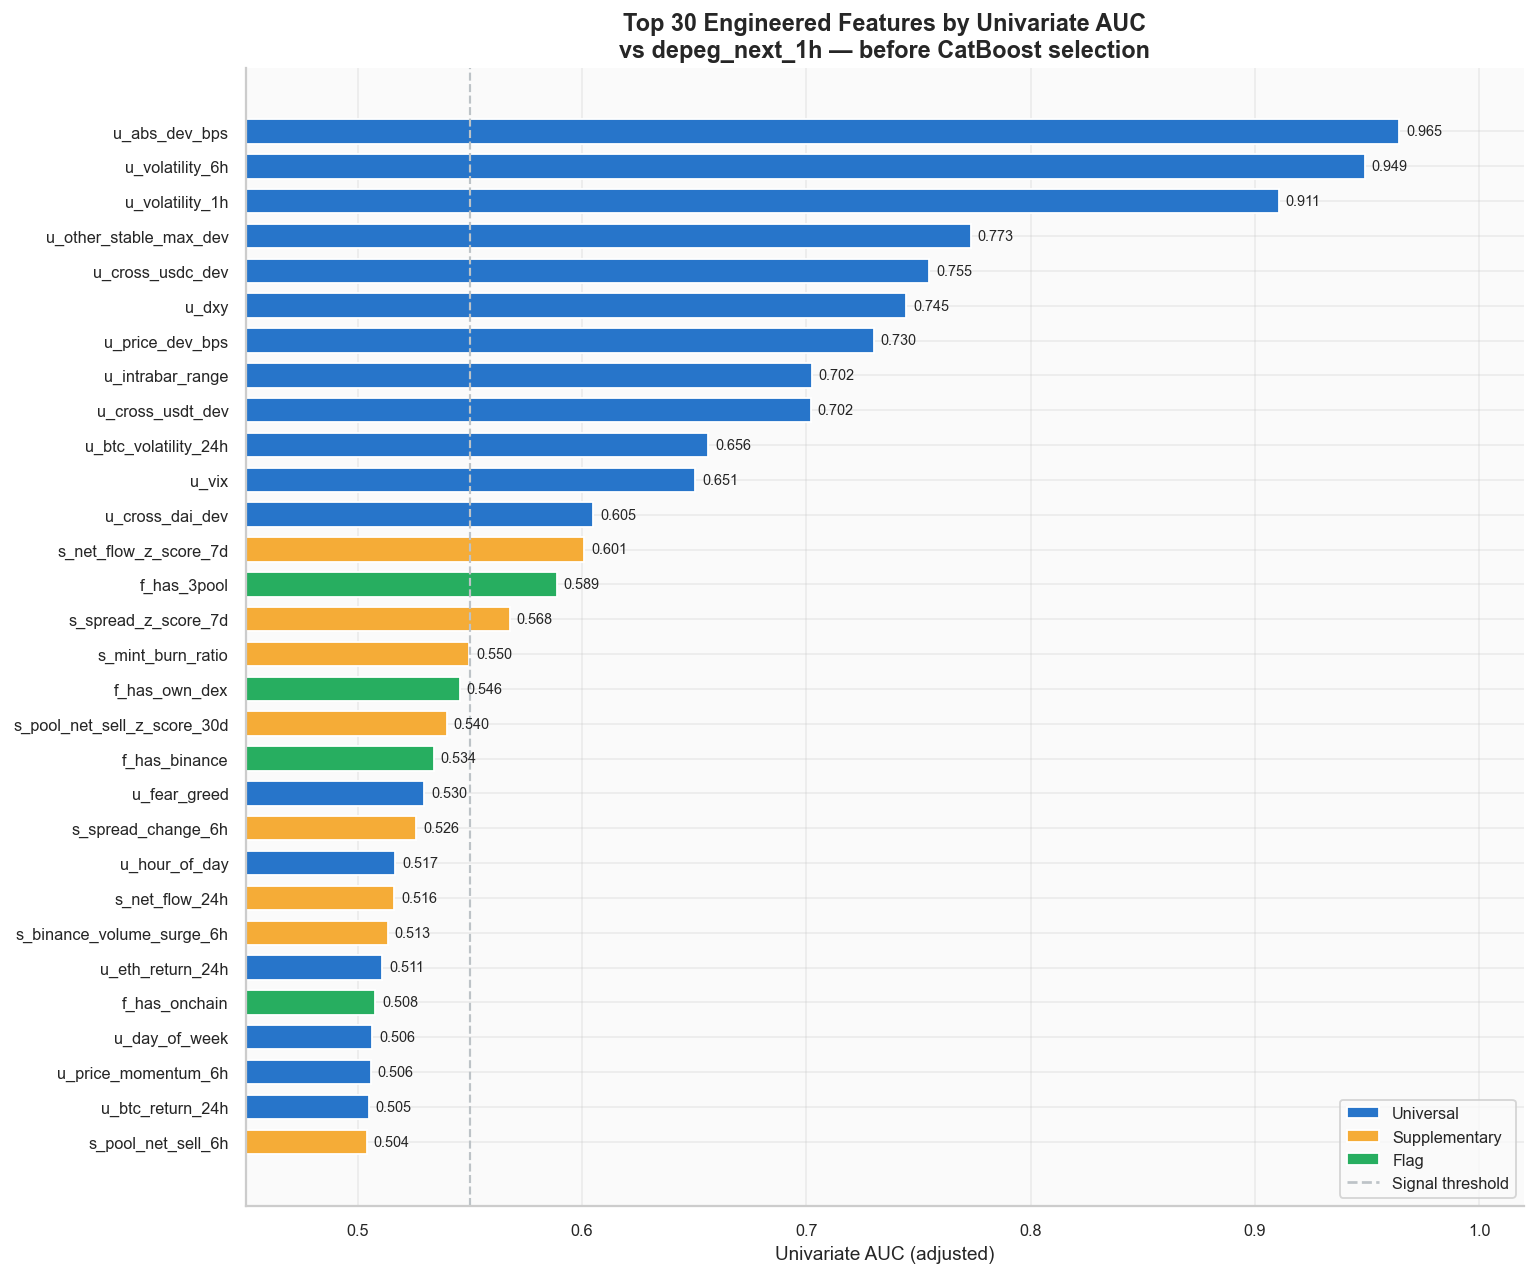

AUC ranking chart completed in 0.3s


In [ ]:
t0 = time.time()

TYPE_COLORS = {
    'universal':     ACCENT,
    'supplementary': ORANGE,
    'flag':          GREEN,
}

top30 = auc_df.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(
    top30['feature'][::-1], top30['auc'][::-1],
    color=[TYPE_COLORS[t] for t in top30['type'][::-1]],
    edgecolor='white', height=0.7
)
for b in bars:
    ax.text(b.get_width()+0.003, b.get_y()+b.get_height()/2,
            f'{b.get_width():.3f}', va='center', fontsize=8)

ax.axvline(0.55, color=LGRAY, lw=1.2, ls='--', label='Signal threshold (0.55)')
ax.set_xlim(0.45, 1.02)
ax.set(xlabel='Univariate AUC (adjusted)', ylabel='',
       title='Top 30 Engineered Features by Univariate AUC\nvs depeg_next_1h — before CatBoost selection')

ax.legend(
    handles=[
        Patch(facecolor=ACCENT,  label='Universal'),
        Patch(facecolor=ORANGE,  label='Supplementary'),
        Patch(facecolor=GREEN,   label='Flag'),
        plt.Line2D([0],[0], color=LGRAY, ls='--', label='Signal threshold'),
    ],
    fontsize=9, loc='lower right'
)
sns.despine()
plt.tight_layout()
plt.show()
print(f'AUC ranking chart completed in {time.time()-t0:.1f}s')

## 10. CatBoost Feature Selection

We use CatBoost's built-in `select_features()` method. It runs forward
and backward passes and returns the optimal subset — it does NOT produce
the final model. We test three thresholds (15, 20, 25 features) and
compare validation AUC to find the best count.

`train_final_model=False` keeps selection and final training cleanly
separated. The final model is trained in Notebook 3.

In [14]:
t0 = time.time()

'''
Prepare the train/val split for feature selection.
We use the chronological 70% for train and 70-85% for validation.
The test set (85-100%) is untouched until Notebook 3.
'''

# drop rows where either target is NaN — typically the last few rows per coin
pool_clean = pooled.dropna(subset=['depeg_next_1h', 'depeg_next_30min']).copy()

n         = len(pool_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = pool_clean.iloc[:train_end].copy()
val   = pool_clean.iloc[train_end:val_end].copy()
test  = pool_clean.iloc[val_end:].copy()   # held back — Notebook 3 only

print(f'Total rows:  {n:,}')
print(f'Train:       {len(train):,} rows  ({len(train)/n*100:.0f}%)  '
      f'up to {train.index.max().date()}')
print(f'Validation:  {len(val):,} rows  ({len(val)/n*100:.0f}%)  '
      f'{val.index.min().date()} to {val.index.max().date()}')
print(f'Test:        {len(test):,} rows  ({len(test)/n*100:.0f}%)  '
      f'from {test.index.min().date()} (untouched until Notebook 3)')

print(f'\nSplit completed in {time.time()-t0:.1f}s')

Total rows:  3,101,405
Train:       2,170,983 rows  (70%)  up to 2024-02-26
Validation:  465,211 rows  (15%)  2024-02-26 to 2025-04-11
Test:        465,211 rows  (15%)  from 2025-04-11 (untouched until Notebook 3)

Split completed in 0.9s


In [15]:
t0 = time.time()

'''
CatBoost feature selection — subsampled to 200K rows to avoid RAM overflow.
Feature ranking on a representative sample is nearly identical to the full
dataset. The final model in Notebook 3 trains on the full dataset.
'''

# episode-proportional sample weights
# weight = (coin_episodes / total_episodes) / (coin_rows / total_rows)
COIN_WEIGHTS = {
    'usdt':  0.9712,
    'usdc':  0.4163,
    'dai':   2.2798,
    'busd':  0.1277,
    'ust':   1.1562,
    'usde':  0.0707,
    'rlusd': 0.0000,
}

train['sample_weight'] = train['coin'].map(COIN_WEIGHTS).fillna(0)
val['sample_weight']   = val['coin'].map(COIN_WEIGHTS).fillna(0)

# cb_feats = all numeric features + categorical coin type
# this is the full candidate set passed to select_features()
cb_feats = num_feats + cat_cols

# subsample training data for selection only
SELECTION_SAMPLE = 200_000
rng          = np.random.RandomState(42)
sample_idx   = rng.choice(len(train),
                           size=min(SELECTION_SAMPLE, len(train)),
                           replace=False)
train_sample = train.iloc[sorted(sample_idx)]

X_train_sel = train_sample[cb_feats].fillna(np.nan)
y_train_sel = train_sample[TARGET].astype(int)
w_train_sel = train_sample['sample_weight'].values

X_val = val[cb_feats].fillna(np.nan)
y_val = val[TARGET].astype(int)
w_val = val['sample_weight'].values

cat_feature_indices = [cb_feats.index('u_coin_type')]

train_pool_sel = Pool(X_train_sel, y_train_sel,
                      cat_features=cat_feature_indices,
                      weight=w_train_sel, feature_names=cb_feats)
val_pool_sel   = Pool(X_val, y_val,
                      cat_features=cat_feature_indices,
                      weight=w_val, feature_names=cb_feats)

# base CatBoost params — used only for selection step
# Notebook 3 redefines with full iterations=500, depth=6 for final model
BASE_CB_PARAMS = dict(
    loss_function         = 'Logloss',
    eval_metric           = 'AUC',
    auto_class_weights    = 'Balanced',
    early_stopping_rounds = 50,
    random_seed           = 42,
    verbose               = False,
)

# lighter config for selection — less RAM, enough signal for ranking
SELECTION_PARAMS = {
    **BASE_CB_PARAMS,
    'iterations':         100,
    'depth':              4,
    'max_ctr_complexity': 1,
}

selection_results = {}
THRESHOLDS = [15, 20, 25]

for n_feats in THRESHOLDS:
    print(f'Running feature selection — target {n_feats} features...')
    t1 = time.time()

    model   = CatBoostClassifier(**SELECTION_PARAMS)
    summary = model.select_features(
        train_pool_sel,
        eval_set               = val_pool_sel,
        features_for_select    = cb_feats,
        num_features_to_select = n_feats,
        steps                  = 1,
        algorithm              = 'RecursiveByLossFunctionChange',
        shap_calc_type         = 'Regular',
        train_final_model      = False,
        logging_level          = 'Silent',
        plot                   = False,
    )

    selected = summary['selected_features_names']

    # quick eval model on selected features to get validation AUC
    eval_model = CatBoostClassifier(**SELECTION_PARAMS)
    cat_idx_sel = [selected.index('u_coin_type')] if 'u_coin_type' in selected else []
    eval_model.fit(
        Pool(X_train_sel[selected], y_train_sel,
             cat_features=cat_idx_sel, weight=w_train_sel,
             feature_names=selected),
        eval_set=Pool(X_val[selected], y_val,
                      cat_features=cat_idx_sel, weight=w_val,
                      feature_names=selected),
        verbose=False,
    )
    val_auc = eval_model.get_best_score()['validation']['AUC']

    selection_results[n_feats] = {
        'selected':  selected,
        'val_auc':   round(val_auc, 4),
        'n_removed': len(cb_feats) - n_feats,
    }
    print(f'  {n_feats} features | val AUC = {val_auc:.4f} | '
          f'took {time.time()-t1:.0f}s')

print(f'\nAll threshold runs completed in {time.time()-t0:.1f}s')

Running feature selection — target 15 features...
  15 features | val AUC = 0.9748 | took 5s
Running feature selection — target 20 features...
  20 features | val AUC = 0.9739 | took 6s
Running feature selection — target 25 features...
  25 features | val AUC = 0.9880 | took 5s

All threshold runs completed in 16.7s


In [16]:
t0 = time.time()

# compare threshold results and pick the best
results_df = pd.DataFrame([{
    'N features':       n,
    'Val AUC':          selection_results[n]['val_auc'],
    'Features removed': selection_results[n]['n_removed'],
} for n in THRESHOLDS])
display(results_df)

best_n             = max(THRESHOLDS, key=lambda n: selection_results[n]['val_auc'])
SELECTED_FEATURES  = selection_results[best_n]['selected']

print(f'\nBest threshold: {best_n} features  '
      f'(val AUC = {selection_results[best_n]["val_auc"]:.4f})')
print(f'\nSelected features ({len(SELECTED_FEATURES)}):')
for f in sorted(SELECTED_FEATURES):
    print(f'  {f}')

print(f'\nThreshold comparison completed in {time.time()-t0:.1f}s')

,N features,Val AUC,Features removed
0,15,0.9748,31
1,20,0.9739,26
2,25,0.9880,21



Best threshold: 25 features  (val AUC = 0.9880)

Selected features (25):
  f_has_3pool
  f_has_own_dex
  s_buy_ratio_change_6h
  s_mint_burn_ratio
  s_net_flow_24h
  s_net_flow_lag3
  s_net_flow_lag6
  s_pool_net_sell_1h
  s_pool_net_sell_lag12
  s_spread_z_score_7d
  u_abnormal_volume_flag
  u_abs_dev_bps
  u_cross_dai_dev
  u_cross_usdt_dev
  u_day_of_week
  u_hour_of_day
  u_intrabar_range
  u_price_dev_bps
  u_price_momentum_6h
  u_price_z_score_7d
  u_vix
  u_volatility_1h
  u_volatility_6h
  u_volume_surge_6h
  u_volume_z_score_7d

Threshold comparison completed in 0.0s


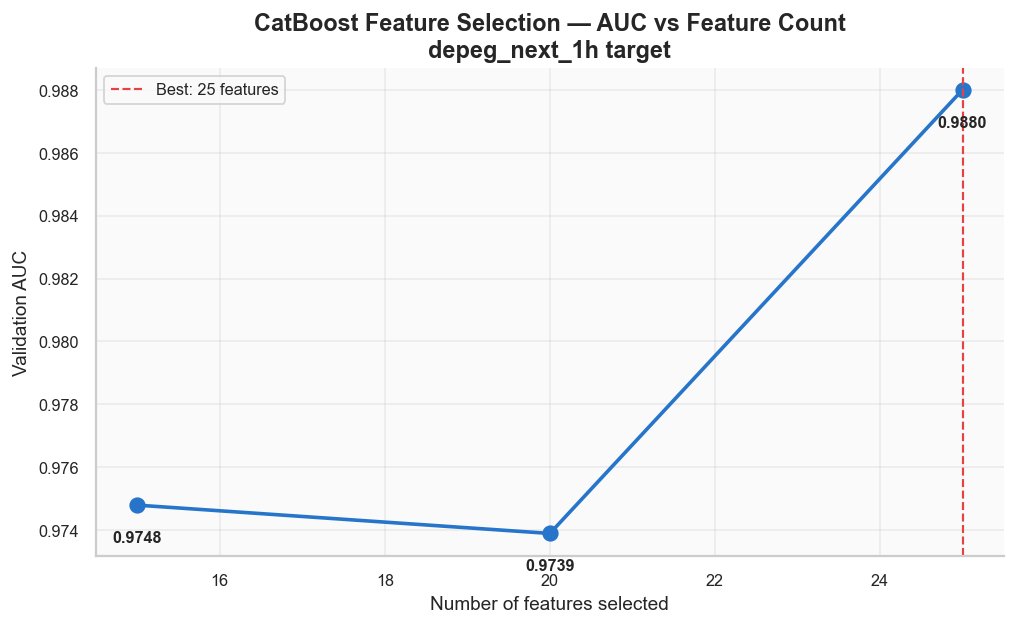

Selection chart completed in 0.1s


In [ ]:
t0 = time.time()

# AUC vs feature count chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    list(selection_results.keys()),
    [selection_results[n]['val_auc'] for n in THRESHOLDS],
    color=ACCENT, lw=2, marker='o', markersize=8
)

# labels below the line to avoid overlapping the title
for n in THRESHOLDS:
    ax.text(n, selection_results[n]['val_auc'] - 0.0008,
            f'{selection_results[n]["val_auc"]:.4f}',
            ha='center', va='top', fontsize=9, fontweight='bold')

ax.axvline(best_n, color=RED, lw=1.2, ls='--', label=f'Best: {best_n} features')
ax.set(xlabel='Number of features selected', ylabel='Validation AUC',
       title='CatBoost Feature Selection — AUC vs Feature Count\ndepeg_next_1h target')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print(f'Selection chart completed in {time.time()-t0:.1f}s')

## 11. Post-Selection Feature Analysis

Added 2 selected features with no univariate AUC:
  u_volume_surge_6h  (categorical or sparse positives — not a quality concern)
  u_volume_z_score_7d  (categorical or sparse positives — not a quality concern)


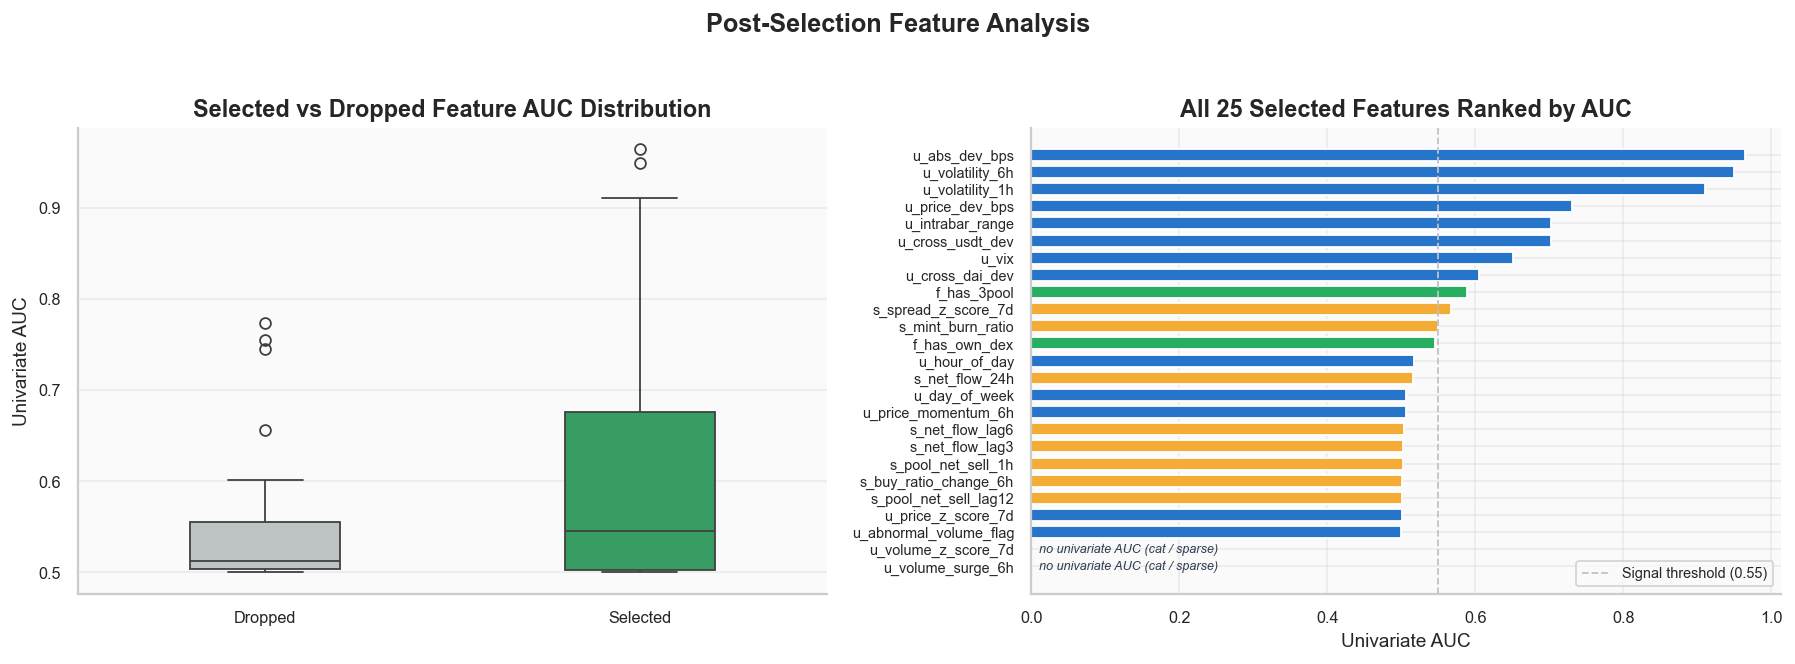

Post-selection analysis completed in 0.3s


In [ ]:
t0 = time.time()

# mark selected vs dropped in auc_df
selected_set           = set(SELECTED_FEATURES)
auc_df['selected']     = auc_df['feature'].isin(selected_set)
auc_df['selected_label'] = auc_df['selected'].map(
    {True: 'Selected', False: 'Dropped'}
)

# add back selected features that were absent from univariate AUC
# (categorical u_coin_type and any that were skipped due to sparse positives)
missing_feats = [f for f in SELECTED_FEATURES
                 if f not in auc_df['feature'].values]
if missing_feats:
    missing_rows = pd.DataFrame({
        'feature':        missing_feats,
        'auc':            np.nan,
        'type':           ['unknown'] * len(missing_feats),
        'selected':       True,
        'selected_label': 'Selected',
    })
    auc_df = pd.concat([auc_df, missing_rows], ignore_index=True)
    print(f'Added {len(missing_feats)} selected features with no univariate AUC:')
    for f in missing_feats:
        print(f'  {f}  (categorical or sparse positives — not a quality concern)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# chart 1 — selected vs dropped AUC box plot
# include only numeric features in auc_df — u_coin_type not in num_feats
sns.boxplot(
    data=auc_df[auc_df['feature'].isin(num_feats)],
    x='selected_label', y='auc',
    order=['Dropped', 'Selected'],
    palette={'Selected': GREEN, 'Dropped': LGRAY},
    ax=axes[0], width=0.4
)
axes[0].set(xlabel='', ylabel='Univariate AUC',
            title='Selected vs Dropped Feature AUC Distribution')
sns.despine(ax=axes[0])

# chart 2 — all selected features ranked by AUC
# NaN features appear at the bottom with a zero-length bar
sel_auc = (auc_df[auc_df['selected']]
           .sort_values('auc', ascending=True, na_position='first'))

axes[1].barh(
    sel_auc['feature'], sel_auc['auc'].fillna(0),
    color=[TYPE_COLORS.get(t, LGRAY) for t in sel_auc['type']],
    edgecolor='white', height=0.7
)

# annotate NaN features — not a problem, explain why
for _, row in sel_auc[sel_auc['auc'].isna()].iterrows():
    feat_idx = list(sel_auc['feature']).index(row['feature'])
    axes[1].text(0.01, feat_idx, 'no univariate AUC (cat / sparse)',
                 va='center', fontsize=7, color=DARK, style='italic')

axes[1].axvline(0.55, color=LGRAY, lw=1, ls='--', label='Signal threshold (0.55)')
axes[1].set(xlabel='Univariate AUC', ylabel='',
            title=f'All {len(sel_auc)} Selected Features Ranked by AUC')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1])

fig.suptitle('Post-Selection Feature Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Post-selection analysis completed in {time.time()-t0:.1f}s')

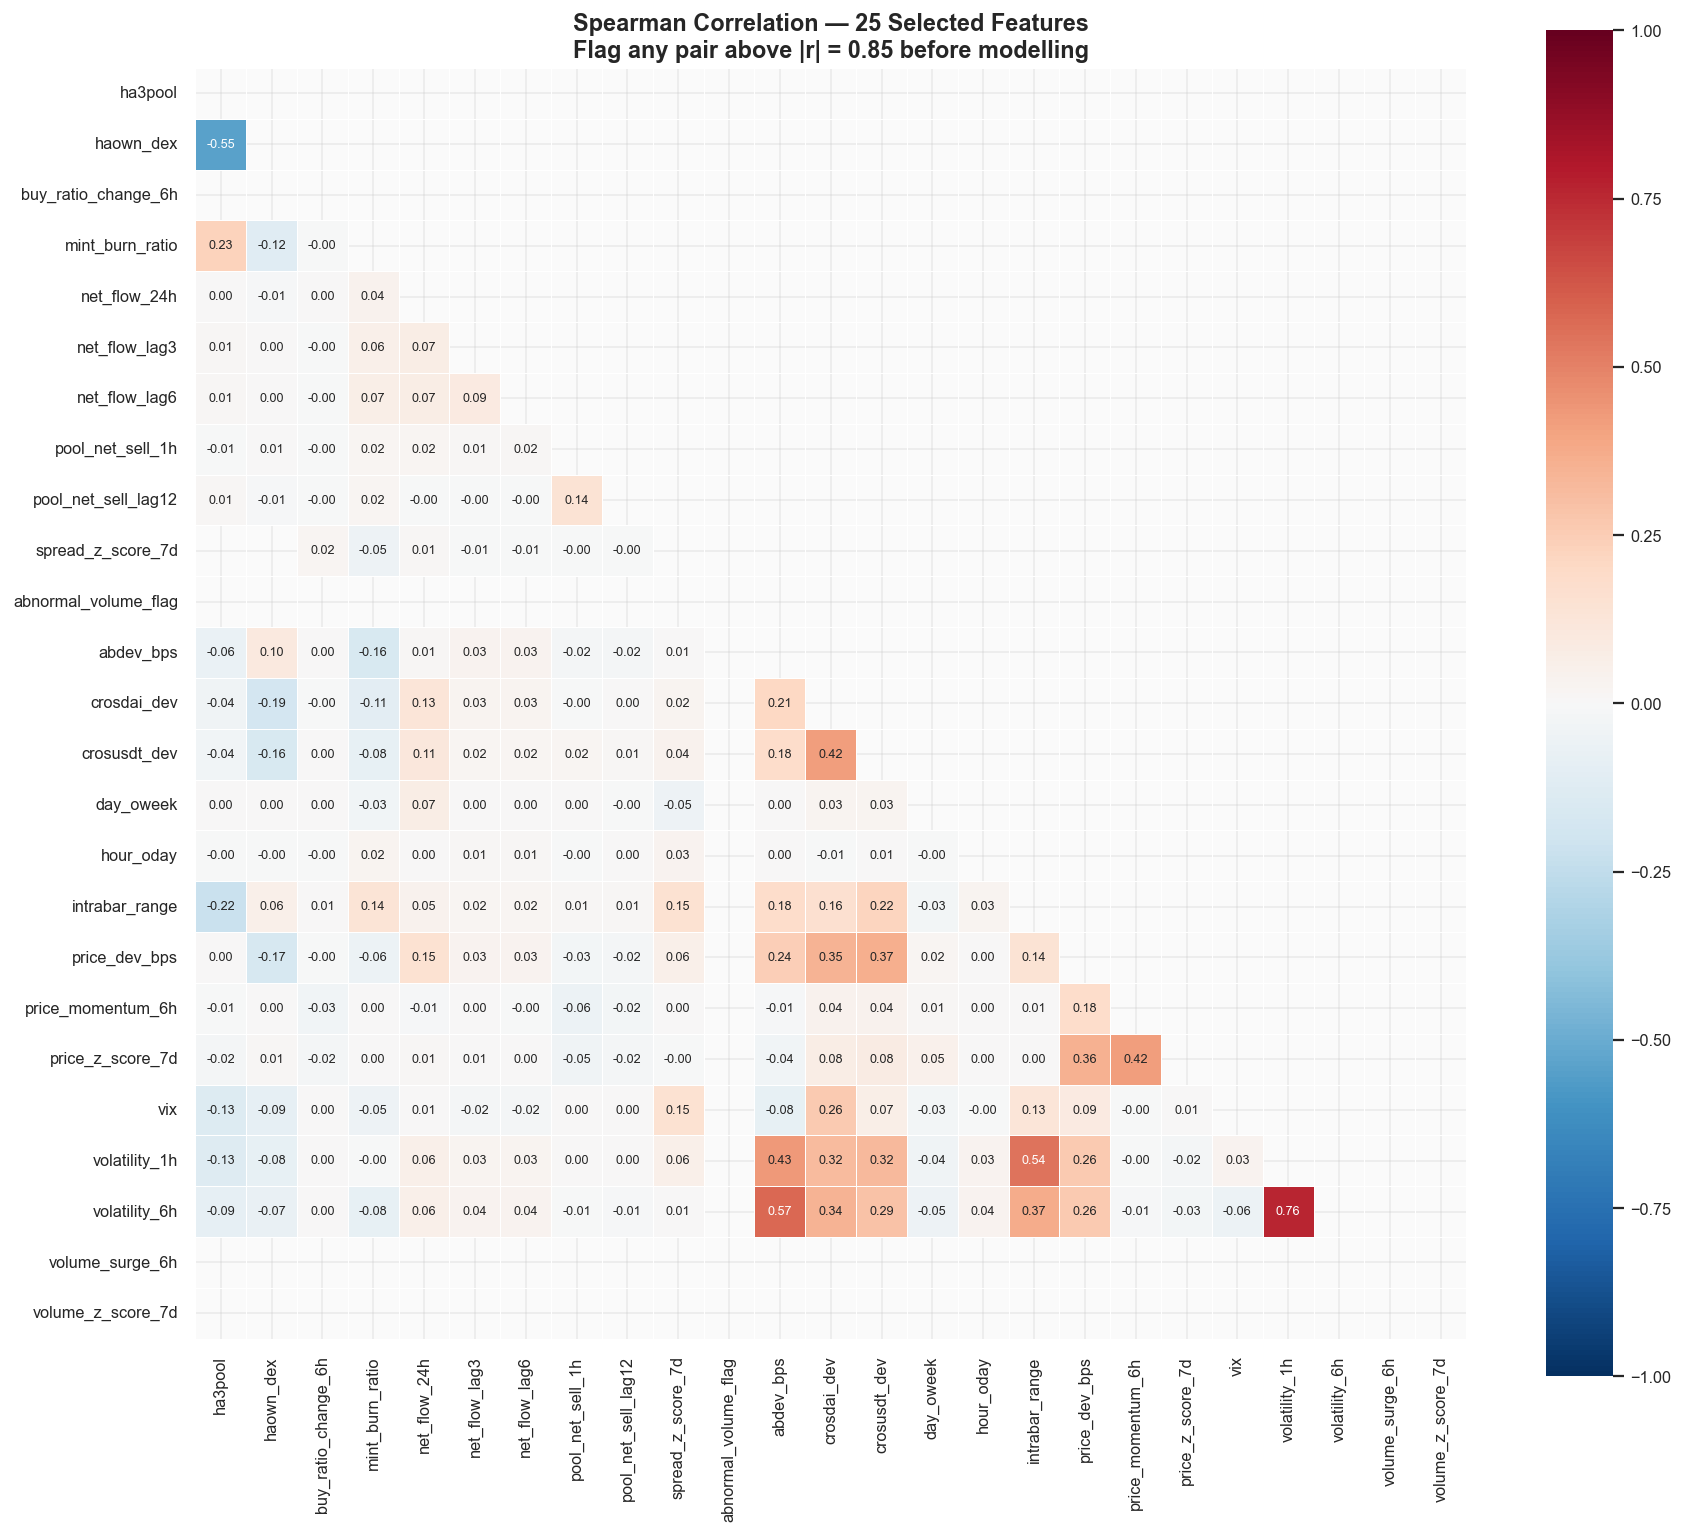

Pairs exceeding |r| > 0.85:
  None — all selected features are below the 0.85 threshold

Correlation check completed in 104.3s


In [ ]:
t0 = time.time()

# Spearman correlation heatmap of selected features
# flag any pair above |r| = 0.85 before modelling
sel_num = [f for f in SELECTED_FEATURES if f != 'u_coin_type']
corr    = pooled[sel_num].corr(method='spearman')

short = [c.replace('u_','').replace('s_','').replace('f_','')[:20] for c in sel_num]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 7}, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4,
    xticklabels=short, yticklabels=short, ax=ax
)
ax.set_title(f'Spearman Correlation — {len(sel_num)} Selected Features\n'
             'Flag any pair above |r| = 0.85 before modelling',
             fontweight='bold')
plt.tight_layout()

plt.show()

print('Pairs exceeding |r| > 0.85:')
found = False
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i,j]) > 0.85:
            print(f'  {corr.index[i]} <> {corr.columns[j]}: r={corr.iloc[i,j]:.3f}')
            found = True
if not found:
    print('  None — all selected features are below the 0.85 threshold')

print(f'\nCorrelation check completed in {time.time()-t0:.1f}s')

## 12. Write Output

In [23]:
t0 = time.time()

output_cols = (
    ["coin", "depeg", "depeg_next_1h", "depeg_next_30min", "severity"]
    + [f for f in SELECTED_FEATURES]
)
output_cols = [c for c in output_cols if c in pool_clean.columns]

final = pool_clean[output_cols].copy()

local_out = FEATURES_DIR / "pooled_5m.parquet"
final.to_parquet(local_out)

size_mb = local_out.stat().st_size / 1e6
print(f"Saved: {local_out}")
print(f"Shape: {final.shape[0]:,} rows x {final.shape[1]} cols  ({size_mb:.1f} MB)")
print(f"Targets:")
print(f"  depeg_next_1h    = 1: {int(final['depeg_next_1h'].sum()):,} ({final['depeg_next_1h'].mean():.3%})")
print(f"  depeg_next_30min = 1: {int(final['depeg_next_30min'].sum()):,} ({final['depeg_next_30min'].mean():.3%})")
print(f"Write completed in {time.time()-t0:.1f}s")

Saved: ../data/processed/features/pooled_5m.parquet
Shape: 3,101,405 rows x 30 cols  (276.4 MB)
Targets:
  depeg_next_1h    = 1: 23,163 (0.747%)
  depeg_next_30min = 1: 14,518 (0.468%)
Write completed in 1.2s
